# Create RDS files for Seurat Label Transfer
* Xenium AnnData -> RDS
* Reference AnnData -> RDS

In [1]:
library(Seurat)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [ ]:
source("../../config/paths.R")

adata_dir   <- file.path(BASE_DIR, "data/rds/xenium")
refdata_dir <- file.path(BASE_DIR, "data/rds/refdata")

In [3]:
load_seurat_from_csv <- function(dataset_dir, project_name) {

  message("Loading dataset from: ", dataset_dir)

  # Determine assay name
  assay_name <- if (grepl("xenium", project_name, ignore.case = TRUE)) "Xenium" else "RNA"

  # Load counts
  zip_file <- file.path(dataset_dir, "counts_matrix.zip")
  stopifnot(file.exists(zip_file))

  tmpdir <- tempfile()
  dir.create(tmpdir)
  unzip(zip_file, exdir = tmpdir)

  mtx_file      <- file.path(tmpdir, "matrix.mtx.gz")
  barcodes_file <- file.path(tmpdir, "barcodes.tsv.gz")
  features_file <- file.path(tmpdir, "features.tsv.gz")
  cell_md_file  <- file.path(dataset_dir, "metadata", "cell-metadata.csv")

  stopifnot(file.exists(mtx_file))
  stopifnot(file.exists(barcodes_file))
  stopifnot(file.exists(features_file))
  stopifnot(file.exists(cell_md_file))

  counts_matrix <- ReadMtx(
    mtx            = mtx_file,
    cells          = barcodes_file,
    features       = features_file,
    feature.column = 1
  )

  # Build Seurat object
  seu <- CreateSeuratObject(counts = counts_matrix, project = project_name)

  # Rename assay for Xenium
  if (assay_name == "Xenium") {
    seu <- RenameAssays(seu, RNA = "Xenium")
  }

  # Load cell metadata
  md <- read.csv(cell_md_file)
  rownames(md) <- md[,1]
  md <- md[,-1, drop = FALSE]
  md <- md[colnames(seu), , drop = FALSE]
  seu <- AddMetaData(seu, md)

  # Load feature metadata
  feature_metadata_file <- file.path(dataset_dir, "metadata", "feature-metadata.csv")
  stopifnot(file.exists(feature_metadata_file))

  feature_metadata <- read.csv(feature_metadata_file)
  rownames(feature_metadata) <- feature_metadata[,1]

  common_genes <- intersect(rownames(seu), rownames(feature_metadata))
  feature_metadata <- feature_metadata[common_genes, , drop = FALSE]

  for (colname in colnames(feature_metadata)) {
    seu[[colname]] <- feature_metadata[[colname]]
  }

  # Load dimensional reductions
  reduc_dir <- file.path(dataset_dir, "reductions")

  latent_file <- file.path(reduc_dir, "latent_representation.csv")
  umap_file   <- file.path(reduc_dir, "umap.csv")

  stopifnot(file.exists(latent_file))
  stopifnot(file.exists(umap_file))

  latent <- read.csv(latent_file, row.names = 1)
  colnames(latent) <- paste0("latent_", seq_len(ncol(latent)))
  seu[["latent"]] <- CreateDimReducObject(as.matrix(latent), key = "latent_", assay = assay_name)

  umap <- read.csv(umap_file, row.names = 1)
  colnames(umap) <- paste0("umap_", seq_len(ncol(umap)))
  seu[["umap"]] <- CreateDimReducObject(as.matrix(umap), key = "UMAP_", assay = assay_name)

  return(seu)
}

In [4]:
adata_seurat   <- load_seurat_from_csv(adata_dir,   project_name = "adata_xenium")
refdata_seurat <- load_seurat_from_csv(refdata_dir, project_name = "refdata_seq")

Loading dataset from: /home/workspace/projects/drg/data/rds/xenium

Renaming default assay from RNA to Xenium

Warning message:
“Key ‘rna_’ taken, using ‘xenium_’ instead”
Loading dataset from: /home/workspace/projects/drg/data/rds/refdata



In [5]:
# Save both .RDS outputs
save_dir <- "/home/workspace/projects/drg/data/rds/seurat"
dir.create(save_dir, recursive = TRUE, showWarnings = FALSE)

saveRDS(adata_seurat,   file = file.path(save_dir, "adata-xenium.rds"))
saveRDS(refdata_seurat, file = file.path(save_dir, "refdata-seq.rds"))

message("Saved RDS files:")
message(" - ", file.path(save_dir, "adata-xenium.rds"))
message(" - ", file.path(save_dir, "refdata-seq.rds"))

Saved RDS files:

 - /home/workspace/projects/drg/data/rds/seurat/adata-xenium.rds

 - /home/workspace/projects/drg/data/rds/seurat/refdata-seq.rds



Successfully loaded:

  - /home/workspace/projects/drg/data/rds/seurat/adata-xenium.rds

  - /home/workspace/projects/drg/data/rds/seurat/refdata-seq.rds

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



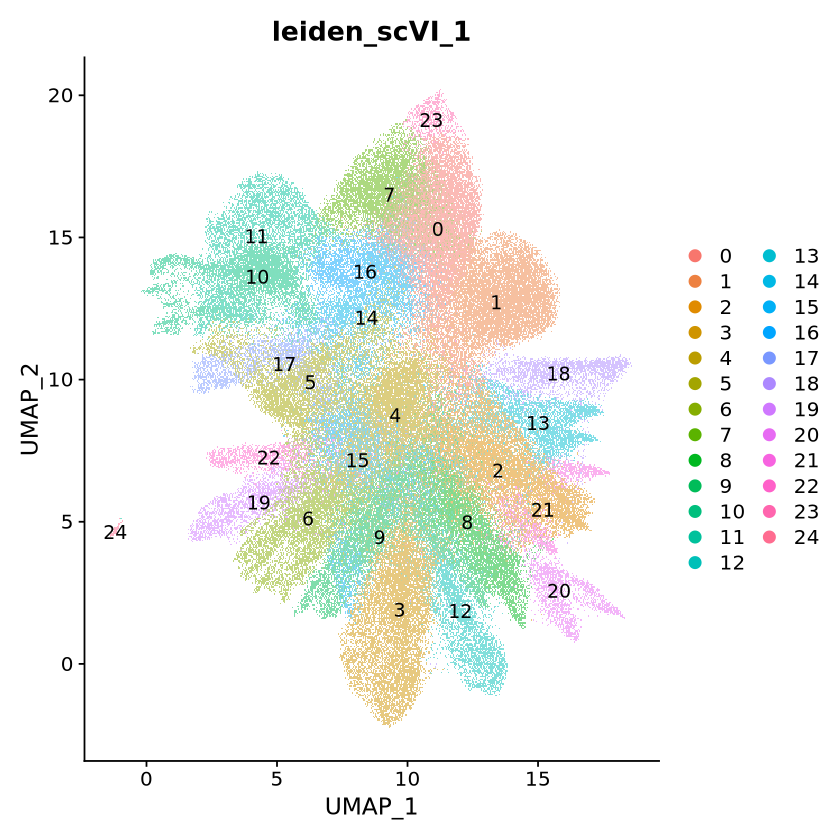

Warning message:
“The following requested variables were not found: cell_labels”


ERROR: Error in `[.data.frame`(data, , group): undefined columns selected


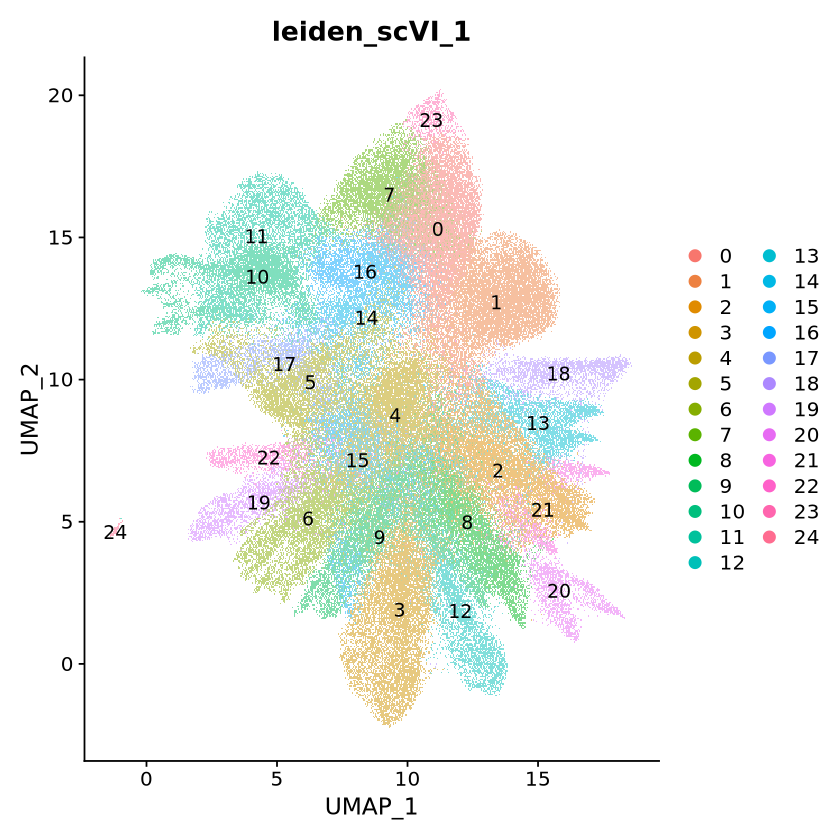

In [6]:
# test import and visualize umap
adata_rds   <- file.path(save_dir, "adata-xenium.rds")
refdata_rds <- file.path(save_dir, "refdata-seq.rds")

# Load Seurat objects
adata_seurat   <- readRDS(adata_rds)
refdata_seurat <- readRDS(refdata_rds)

message("Successfully loaded:")
message("  - ", adata_rds)
message("  - ", refdata_rds)

####################################################################################################
# UMAP VISUALIZATION (adata)
####################################################################################################

# UMAP by cell type
DimPlot(
  adata_seurat,
  reduction = "umap",
  group.by  = "leiden_scVI_1",
  label     = TRUE,
  pt.size   = 0.5
)

# UMAP by Leiden
DimPlot(
  adata_seurat,
  reduction = "umap",
  group.by  = "leiden_scVI_1",
  label     = TRUE,
  pt.size   = 0.5
)

# RefData UMAP

DimPlot(
  refdata_seurat,
  reduction = "umap",
  group.by  = "cell_labels",
  label     = TRUE,
  pt.size   = 0.5
)